In [1]:
!pip install simpy

In [2]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Number of machines
NUM_WASHERS     = 6
NUM_DRYERS      = 8
NUM_FOLD_TABLES = 3
NUM_SOAP_MACHINES = 2

# Cycle times (in minutes)
WASH_TIME       = 35    # deterministic — always 35 min
DRY_TIME_MIN    = 45    # stochastic — random between 45 and 60 min
DRY_TIME_MAX    = 60
FOLD_TIME_MIN   = 6
FOLD_TIME_MAX   = 11
DETERGENT_TIME_MIN = 1  # time at soap vending machine
DETERGENT_TIME_MAX = 3
LOADING_TIME_MIN   = 2  # time to load clothes into washer
LOADING_TIME_MAX   = 3
TRANSFER_TIME_MIN  = 0  # time between washer and dryer (customer steps away)
TRANSFER_TIME_MAX  = 5

# Arrival rates (customers per minute)
ARRIVAL_RATE_NORMAL = 0.18   # off-peak: 1 customer every ~5.5 min
ARRIVAL_RATE_PEAK   = 0.45   # peak hours: 1 customer every ~2.2 min

# Simulation time (in minutes, starting from 08:00)
SIM_DURATION = 720   # 720 minutes = 12 hours (08:00 to 20:00)

# Peak hours (minutes from 08:00)
PEAK_START_1 = 60    # 09:00
PEAK_END_1   = 180   # 11:00
PEAK_START_2 = 300   # 13:00
PEAK_END_2   = 420   # 15:00

# Random seed for reproducibility
random.seed(42)

print("Parameters set!")
print(f"Washers: {NUM_WASHERS}  |  Dryers: {NUM_DRYERS}  |  Fold Tables: {NUM_FOLD_TABLES}  |  Soap Machines: {NUM_SOAP_MACHINES}")

Parameters set!
Washers: 6  |  Dryers: 8  |  Fold Tables: 3  |  Soap Machines: 2


In [4]:
# Waiting times — one entry per customer
wash_wait_times  = []   # how long each customer waited for a washer
dry_wait_times   = []   # how long each customer waited for a dryer (bottleneck)
total_times      = []   # how long each customer spent in the laundromat

# Queue lengths over time — one entry every 5 minutes
time_log         = []   # simulation clock at each snapshot
wash_queue_log   = []   # washer queue length at each snapshot
dry_queue_log    = []   # dryer queue length at each snapshot

# Counters
customers_arrived = 0
customers_served  = 0

print("Data collection lists ready!")

Data collection lists ready!


In [5]:
def to_clock(t):
    # Simulation starts at 08:00, so we add 480 minutes (8 hours)
    total_minutes = int(480 + t)
    hours   = total_minutes // 60
    minutes = total_minutes % 60
    return f"{hours:02d}:{minutes:02d}"

print(f"to_clock(0)   = {to_clock(0)}")    # should print 08:00
print(f"to_clock(60)  = {to_clock(60)}")   # should print 09:00
print(f"to_clock(720) = {to_clock(720)}")  # should print 20:00

to_clock(0)   = 08:00
to_clock(60)  = 09:00
to_clock(720) = 20:00


In [6]:
def customer(env, name, n_baskets, soap_machine, washer, dryer, fold_table):

    # ── EVENT 1: CUSTOMER ARRIVES ────────────────────────────
    arrival_time = env.now
    print(f"{to_clock(env.now)} | {name} arrives with {n_baskets} basket(s)")

    # ── EVENT 2: PURCHASE DETERGENT AT SOAP VENDING MACHINE ──
    # The soap machine is a resource — if both are busy, wait in line
    with soap_machine.request() as soap_req:
        yield soap_req   # wait until soap machine is available (FIFO)

        detergent_time = random.uniform(DETERGENT_TIME_MIN, DETERGENT_TIME_MAX)
        print(f"{to_clock(env.now)} | {name} at soap counter (detergent = {detergent_time:.1f} min)")

        yield env.timeout(detergent_time)   # wait while getting detergent

        print(f"{to_clock(env.now)} | {name} has detergent, heading to washer")
    # soap machine is released here automatically

    # ── EVENT 3: ENTER WASHER QUEUE ──────────────────────────
    # Customer needs one washer per basket they brought
    wash_queue_entry = env.now
    washer_requests = []

    for i in range(n_baskets):
        washer_requests.append(washer.request())   # join the washer queue

    for req in washer_requests:
        yield req   # wait until all requested washers are free (FIFO)

    wash_wait = env.now - wash_queue_entry
    wash_wait_times.append(wash_wait)

    if wash_wait > 1:
        print(f"{to_clock(env.now)} | {name} waited {wash_wait:.1f} min for washer")

    # ── EVENT 4: LOAD CLOTHES AND DETERGENT INTO WASHER ──────
    # Per proposal: customer spends 2-3 min loading
    loading_time = random.uniform(LOADING_TIME_MIN, LOADING_TIME_MAX)
    print(f"{to_clock(env.now)} | {name} loading {n_baskets} basket(s) into washer ({loading_time:.1f} min)")

    yield env.timeout(loading_time)   # wait while loading

    # ── EVENT 5: WASH CYCLE STARTS ───────────────────────────
    wash_start = env.now
    wash_duration = WASH_TIME + random.uniform(-1.5, 1.5)   # small jitter
    print(f"{to_clock(env.now)} | {name} wash cycle STARTED ({wash_duration:.1f} min)")

    # ── EVENT 6: WASH CYCLE ENDS ─────────────────────────────
    yield env.timeout(wash_duration)   # wait while washing

    print(f"{to_clock(env.now)} | {name} wash cycle ENDED")

    # Release all washers
    for req in washer_requests:
        washer.release(req)

    # ── TRANSFER DELAY ────────────────────────────────────────
    # Customer may step away between washer and dryer.
    # Proposal assumption: 0 to 5 minute stochastic delay.
    # Wet clothes sit in machine, blocking it for other customers.
    transfer_delay = random.uniform(TRANSFER_TIME_MIN, TRANSFER_TIME_MAX)
    if transfer_delay > 0.5:
        print(f"{to_clock(env.now)} | {name} stepped away — wet clothes in machine ({transfer_delay:.1f} min)")
    yield env.timeout(transfer_delay)

    # ── EVENT 7: ENTER DRYER QUEUE ───────────────────────────
    # This is where the BOTTLENECK happens.
    # Drying takes longer than washing, so all dryers fill up
    # and customers pile up waiting.
    dry_queue_entry = env.now
    dryer_requests = []

    for i in range(n_baskets):
        dryer_requests.append(dryer.request())   # join the dryer queue

    for req in dryer_requests:
        yield req   # wait until all requested dryers are free (FIFO)

    dry_wait = env.now - dry_queue_entry
    dry_wait_times.append(dry_wait)

    if dry_wait > 1:
        print(f"{to_clock(env.now)} | {name} waited {dry_wait:.1f} min for dryer ← BOTTLENECK")

    # ── EVENT 8: DRY CYCLE STARTS ────────────────────────────
    dry_duration = random.uniform(DRY_TIME_MIN, DRY_TIME_MAX)
    print(f"{to_clock(env.now)} | {name} dry cycle STARTED ({dry_duration:.1f} min, waited {dry_wait:.1f} min)")

    # ── EVENT 9: DRY CYCLE ENDS ──────────────────────────────
    yield env.timeout(dry_duration)   # wait while drying

    print(f"{to_clock(env.now)} | {name} dry cycle ENDED")

    # Release all dryers
    for req in dryer_requests:
        dryer.release(req)

    # ── EVENT 10: ENTER FOLDING QUEUE ────────────────────────
    fold_queue_entry = env.now

    with fold_table.request() as fold_req:
        yield fold_req   # wait until a folding table is free (FIFO)

        # ── EVENT 11: FOLDING STARTS ─────────────────────────
        fold_duration = random.uniform(FOLD_TIME_MIN, FOLD_TIME_MAX) * n_baskets
        print(f"{to_clock(env.now)} | {name} folding STARTED ({fold_duration:.1f} min)")

        # ── EVENT 12: FOLDING ENDS ────────────────────────────
        yield env.timeout(fold_duration)   # wait while folding

        print(f"{to_clock(env.now)} | {name} folding ENDED")
    # fold table is released here automatically

    # ── EVENT 13: CUSTOMER DEPARTS ───────────────────────────
    depart_time = env.now
    total_time  = depart_time - arrival_time
    total_times.append(total_time)

    global customers_served
    customers_served += 1

    print(f"{to_clock(env.now)} | {name} DEPARTS — total time: {total_time:.0f} min | dry wait: {dry_wait:.1f} min")
    print(f"{'─'*60}")

print("customer() process defined!")



customer() process defined!


In [7]:
def customer_generator(env, soap_machine, washer, dryer, fold_table):

    cust_number = 1

    while True:

        # Check if we are currently in a peak hour window
        if (PEAK_START_1 <= env.now <= PEAK_END_1) or \
           (PEAK_START_2 <= env.now <= PEAK_END_2):
            rate = ARRIVAL_RATE_PEAK     # faster arrivals during peak
        else:
            rate = ARRIVAL_RATE_NORMAL   # slower arrivals off-peak

        # Draw inter-arrival time from Exponential distribution
        # This creates a Poisson arrival process
        inter_arrival_time = random.expovariate(rate)

        # Wait for the next customer to arrive
        yield env.timeout(inter_arrival_time)

        # Stop generating after closing time
        if env.now >= SIM_DURATION:
            break

        # Assign random number of baskets (1 to 3)
        n_baskets = random.randint(1, 3)

        # Track total arrivals
        global customers_arrived
        customers_arrived += 1

        # Create and launch this customer's process
        name = f"Customer {cust_number}"
        env.process(customer(env, name, n_baskets,
                             soap_machine, washer, dryer, fold_table))

        cust_number += 1

print("customer_generator() defined!")



customer_generator() defined!


In [8]:
def queue_monitor(env, washer, dryer):

    while True:
        # Record current time and queue lengths
        time_log.append(env.now)
        wash_queue_log.append(len(washer.queue))
        dry_queue_log.append(len(dryer.queue))

        # Wait 5 minutes before next snapshot
        yield env.timeout(5)

print("queue_monitor() defined!")


queue_monitor() defined!


In [9]:
print("=" * 60)
print("  RUNNING: Baseline Scenario (6 Washers / 8 Dryers)")
print("=" * 60)

# Reset data collection lists for a fresh run
wash_wait_times  = []
dry_wait_times   = []
total_times      = []
time_log         = []
wash_queue_log   = []
dry_queue_log    = []
customers_arrived = 0
customers_served  = 0

random.seed(42)   # same seed = same results every time

# Step 1: Create the simulation environment (the clock)
env = simpy.Environment()

# Step 2: Create all four resources
# simpy.Resource automatically manages a FIFO queue
soap_machine = simpy.Resource(env, capacity=NUM_SOAP_MACHINES)
washer       = simpy.Resource(env, capacity=NUM_WASHERS)
dryer        = simpy.Resource(env, capacity=NUM_DRYERS)
fold_table   = simpy.Resource(env, capacity=NUM_FOLD_TABLES)

# Step 3: Start the arrival generator process
env.process(customer_generator(env, soap_machine, washer, dryer, fold_table))

# Step 4: Start the queue monitor process
env.process(queue_monitor(env, washer, dryer))

# Step 5: Run the simulation until closing time (720 minutes = 8 PM)
env.run(until=SIM_DURATION)

print("\nSimulation complete!")


  RUNNING: Baseline Scenario (6 Washers / 8 Dryers)
08:05 | Customer 1 arrives with 1 basket(s)
08:05 | Customer 1 at soap counter (detergent = 1.5 min)
08:07 | Customer 1 has detergent, heading to washer
08:07 | Customer 1 loading 1 basket(s) into washer (2.1 min)
08:09 | Customer 1 wash cycle STARTED (33.8 min)
08:13 | Customer 2 arrives with 3 basket(s)
08:13 | Customer 2 at soap counter (detergent = 1.2 min)
08:14 | Customer 2 has detergent, heading to washer
08:14 | Customer 2 loading 3 basket(s) into washer (2.4 min)
08:16 | Customer 2 wash cycle STARTED (33.6 min)
08:25 | Customer 3 arrives with 1 basket(s)
08:25 | Customer 3 at soap counter (detergent = 2.2 min)
08:27 | Customer 4 arrives with 3 basket(s)
08:27 | Customer 4 at soap counter (detergent = 2.3 min)
08:27 | Customer 3 has detergent, heading to washer
08:27 | Customer 3 loading 1 basket(s) into washer (2.5 min)
08:28 | Customer 5 arrives with 1 basket(s)
08:28 | Customer 5 at soap counter (detergent = 1.6 min)
08:29 

In [10]:
print("\n" + "=" * 60)
print("  SIMULATION RESULTS — Baseline (6W / 8D)")
print("=" * 60)

# ── Objective 1: Average waiting times ───────────────────────
if len(dry_wait_times) > 0:
    avg_dry_wait  = sum(dry_wait_times) / len(dry_wait_times)
    max_dry_wait  = max(dry_wait_times)
else:
    avg_dry_wait  = 0
    max_dry_wait  = 0

if len(wash_wait_times) > 0:
    avg_wash_wait = sum(wash_wait_times) / len(wash_wait_times)
else:
    avg_wash_wait = 0

if len(total_times) > 0:
    avg_total_time = sum(total_times) / len(total_times)
else:
    avg_total_time = 0

print(f"\n  Objective 1 — Average Waiting Times:")
print(f"    Avg wait for washer : {avg_wash_wait:.2f} min")
print(f"    Avg wait for dryer  : {avg_dry_wait:.2f} min  ← BOTTLENECK METRIC")
print(f"    Max wait for dryer  : {max_dry_wait:.2f} min")
print(f"    Avg total time      : {avg_total_time:.2f} min")

# ── Objective 2: Utilization rates ───────────────────────────
if len(time_log) > 0:
    avg_wash_util = sum(wash_queue_log) / len(wash_queue_log)
    avg_dry_util  = sum(dry_queue_log)  / len(dry_queue_log)
else:
    avg_wash_util = 0
    avg_dry_util  = 0

if customers_arrived > 0:
    throughput_pct = (customers_served / customers_arrived) * 100
else:
    throughput_pct = 0

print(f"\n  Objective 2 — Utilization Rates:")
print(f"    Customers arrived   : {customers_arrived}")
print(f"    Customers served    : {customers_served}")
print(f"    Throughput rate     : {throughput_pct:.1f}%")
print(f"    Avg washer queue    : {avg_wash_util:.2f} people waiting")
print(f"    Avg dryer queue     : {avg_dry_util:.2f} people waiting")

# ── Objective 3: Bottleneck point ────────────────────────────
if len(dry_wait_times) > 0:
    customers_who_waited = sum(1 for w in dry_wait_times if w > 1)
    pct_who_waited = (customers_who_waited / len(dry_wait_times)) * 100
    peak_dry_queue = max(dry_queue_log) if len(dry_queue_log) > 0 else 0
else:
    customers_who_waited = 0
    pct_who_waited = 0
    peak_dry_queue = 0

print(f"\n  Objective 3 — Dryer Bottleneck:")
print(f"    Customers who waited for dryer : {customers_who_waited}")
print(f"    % of customers who waited      : {pct_who_waited:.1f}%")
print(f"    Peak dryer queue length        : {peak_dry_queue} people")

print("\n" + "=" * 60)


  SIMULATION RESULTS — Baseline (6W / 8D)

  Objective 1 — Average Waiting Times:
    Avg wait for washer : 262.77 min
    Avg wait for dryer  : 18.04 min  ← BOTTLENECK METRIC
    Max wait for dryer  : 53.17 min
    Avg total time      : 318.42 min

  Objective 2 — Utilization Rates:
    Customers arrived   : 190
    Customers served    : 38
    Throughput rate     : 20.0%
    Avg washer queue    : 166.51 people waiting
    Avg dryer queue     : 2.03 people waiting

  Objective 3 — Dryer Bottleneck:
    Customers who waited for dryer : 34
    % of customers who waited      : 75.6%
    Peak dryer queue length        : 10 people



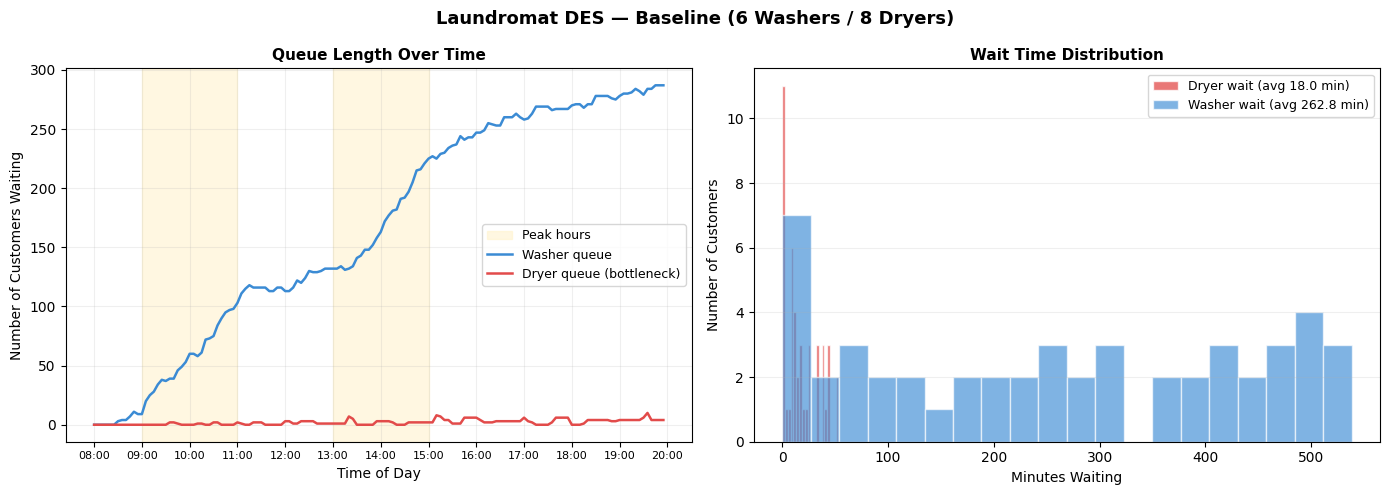

Chart saved: chart_baseline.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Laundromat DES — Baseline (6 Washers / 8 Dryers)",
             fontsize=13, fontweight="bold")

# ── Chart 1: Queue lengths over time ─────────────────────────
ax1 = axes[0]

# Shade peak hour windows in yellow
ax1.axvspan(PEAK_START_1, PEAK_END_1,   color="#FFF3CD", alpha=0.6, label="Peak hours")
ax1.axvspan(PEAK_START_2, PEAK_END_2,   color="#FFF3CD", alpha=0.6)

# Plot queue lines
ax1.plot(time_log, wash_queue_log, color="#3B8BD4", lw=1.8, label="Washer queue")
ax1.plot(time_log, dry_queue_log,  color="#E24B4A", lw=1.8, label="Dryer queue (bottleneck)")

# Format x-axis as clock times
xticks = list(range(0, SIM_DURATION + 1, 60))
xlabels = [to_clock(t) for t in xticks]
ax1.set_xticks(xticks)
ax1.set_xticklabels(xlabels, fontsize=8)

ax1.set_title("Queue Length Over Time",  fontsize=11, fontweight="bold")
ax1.set_xlabel("Time of Day")
ax1.set_ylabel("Number of Customers Waiting")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2)

# ── Chart 2: Wait time histogram ─────────────────────────────
ax2 = axes[1]

if len(dry_wait_times) > 0:
    ax2.hist(dry_wait_times, bins=20, color="#E24B4A", alpha=0.75,
             label=f"Dryer wait (avg {avg_dry_wait:.1f} min)", edgecolor="white")

if len(wash_wait_times) > 0:
    ax2.hist(wash_wait_times, bins=20, color="#3B8BD4", alpha=0.65,
             label=f"Washer wait (avg {avg_wash_wait:.1f} min)", edgecolor="white")

ax2.set_title("Wait Time Distribution",  fontsize=11, fontweight="bold")
ax2.set_xlabel("Minutes Waiting")
ax2.set_ylabel("Number of Customers")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("chart_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: chart_baseline.png")


In [12]:
print("=" * 60)
print("  RUNNING: What-If — More Dryers (6 Washers / 12 Dryers)")
print("=" * 60)

# Reset data for fresh run
wash_wait_times  = []
dry_wait_times   = []
total_times      = []
time_log         = []
wash_queue_log   = []
dry_queue_log    = []
customers_arrived = 0
customers_served  = 0
random.seed(42)

# Create environment and resources with MORE DRYERS
env2         = simpy.Environment()
soap_machine2 = simpy.Resource(env2, capacity=NUM_SOAP_MACHINES)
washer2       = simpy.Resource(env2, capacity=6)    # same washers
dryer2        = simpy.Resource(env2, capacity=12)   # MORE dryers
fold_table2   = simpy.Resource(env2, capacity=NUM_FOLD_TABLES)

env2.process(customer_generator(env2, soap_machine2, washer2, dryer2, fold_table2))
env2.process(queue_monitor(env2, washer2, dryer2))
env2.run(until=SIM_DURATION)

# Results
if len(dry_wait_times) > 0:
    avg_dry_wait2 = sum(dry_wait_times) / len(dry_wait_times)
    peak_q2       = max(dry_queue_log)
else:
    avg_dry_wait2 = 0
    peak_q2       = 0

throughput2 = (customers_served / max(customers_arrived, 1)) * 100
time_log2, wash_q2, dry_q2 = time_log[:], wash_queue_log[:], dry_queue_log[:]

print(f"\n  Avg dryer wait  : {avg_dry_wait2:.2f} min")
print(f"  Peak dryer queue: {peak_q2} people")
print(f"  Throughput rate : {throughput2:.1f}%")



  RUNNING: What-If — More Dryers (6 Washers / 12 Dryers)
08:05 | Customer 1 arrives with 1 basket(s)
08:05 | Customer 1 at soap counter (detergent = 1.5 min)
08:07 | Customer 1 has detergent, heading to washer
08:07 | Customer 1 loading 1 basket(s) into washer (2.1 min)
08:09 | Customer 1 wash cycle STARTED (33.8 min)
08:13 | Customer 2 arrives with 3 basket(s)
08:13 | Customer 2 at soap counter (detergent = 1.2 min)
08:14 | Customer 2 has detergent, heading to washer
08:14 | Customer 2 loading 3 basket(s) into washer (2.4 min)
08:16 | Customer 2 wash cycle STARTED (33.6 min)
08:25 | Customer 3 arrives with 1 basket(s)
08:25 | Customer 3 at soap counter (detergent = 2.2 min)
08:27 | Customer 4 arrives with 3 basket(s)
08:27 | Customer 4 at soap counter (detergent = 2.3 min)
08:27 | Customer 3 has detergent, heading to washer
08:27 | Customer 3 loading 1 basket(s) into washer (2.5 min)
08:28 | Customer 5 arrives with 1 basket(s)
08:28 | Customer 5 at soap counter (detergent = 1.6 min)
0

In [13]:
print("=" * 60)
print("  RUNNING: What-If — Optimal (8 Washers / 10 Dryers)")
print("=" * 60)

wash_wait_times  = []
dry_wait_times   = []
total_times      = []
time_log         = []
wash_queue_log   = []
dry_queue_log    = []
customers_arrived = 0
customers_served  = 0
random.seed(42)

env3          = simpy.Environment()
soap_machine3  = simpy.Resource(env3, capacity=NUM_SOAP_MACHINES)
washer3        = simpy.Resource(env3, capacity=8)    # more washers
dryer3         = simpy.Resource(env3, capacity=10)   # more dryers
fold_table3    = simpy.Resource(env3, capacity=4)    # more fold tables

env3.process(customer_generator(env3, soap_machine3, washer3, dryer3, fold_table3))
env3.process(queue_monitor(env3, washer3, dryer3))
env3.run(until=SIM_DURATION)

if len(dry_wait_times) > 0:
    avg_dry_wait3 = sum(dry_wait_times) / len(dry_wait_times)
    peak_q3       = max(dry_queue_log)
else:
    avg_dry_wait3 = 0
    peak_q3       = 0

throughput3 = (customers_served / max(customers_arrived, 1)) * 100
time_log3, wash_q3, dry_q3 = time_log[:], wash_queue_log[:], dry_queue_log[:]

print(f"\n  Avg dryer wait  : {avg_dry_wait3:.2f} min")
print(f"  Peak dryer queue: {peak_q3} people")
print(f"  Throughput rate : {throughput3:.1f}%")


  RUNNING: What-If — Optimal (8 Washers / 10 Dryers)
08:05 | Customer 1 arrives with 1 basket(s)
08:05 | Customer 1 at soap counter (detergent = 1.5 min)
08:07 | Customer 1 has detergent, heading to washer
08:07 | Customer 1 loading 1 basket(s) into washer (2.1 min)
08:09 | Customer 1 wash cycle STARTED (33.8 min)
08:13 | Customer 2 arrives with 3 basket(s)
08:13 | Customer 2 at soap counter (detergent = 1.2 min)
08:14 | Customer 2 has detergent, heading to washer
08:14 | Customer 2 loading 3 basket(s) into washer (2.4 min)
08:16 | Customer 2 wash cycle STARTED (33.6 min)
08:25 | Customer 3 arrives with 1 basket(s)
08:25 | Customer 3 at soap counter (detergent = 2.2 min)
08:27 | Customer 4 arrives with 3 basket(s)
08:27 | Customer 4 at soap counter (detergent = 2.3 min)
08:27 | Customer 3 has detergent, heading to washer
08:27 | Customer 3 loading 1 basket(s) into washer (2.5 min)
08:28 | Customer 5 arrives with 1 basket(s)
08:28 | Customer 5 at soap counter (detergent = 1.6 min)
08:29

In [14]:
print("=" * 60)
print("  RUNNING: What-If — Peak Stress Test (doubled arrivals)")
print("=" * 60)

wash_wait_times  = []
dry_wait_times   = []
total_times      = []
time_log         = []
wash_queue_log   = []
dry_queue_log    = []
customers_arrived = 0
customers_served  = 0
random.seed(42)

# Temporarily double the peak arrival rate
ARRIVAL_RATE_PEAK = 0.75

env4          = simpy.Environment()
soap_machine4  = simpy.Resource(env4, capacity=NUM_SOAP_MACHINES)
washer4        = simpy.Resource(env4, capacity=6)
dryer4         = simpy.Resource(env4, capacity=8)
fold_table4    = simpy.Resource(env4, capacity=NUM_FOLD_TABLES)

env4.process(customer_generator(env4, soap_machine4, washer4, dryer4, fold_table4))
env4.process(queue_monitor(env4, washer4, dryer4))
env4.run(until=SIM_DURATION)

if len(dry_wait_times) > 0:
    avg_dry_wait4 = sum(dry_wait_times) / len(dry_wait_times)
    peak_q4       = max(dry_queue_log)
else:
    avg_dry_wait4 = 0
    peak_q4       = 0

throughput4 = (customers_served / max(customers_arrived, 1)) * 100
time_log4, wash_q4, dry_q4 = time_log[:], wash_queue_log[:], dry_queue_log[:]

# Reset peak rate back to normal
ARRIVAL_RATE_PEAK = 0.45

print(f"\n  Avg dryer wait  : {avg_dry_wait4:.2f} min")
print(f"  Peak dryer queue: {peak_q4} people")
print(f"  Throughput rate : {throughput4:.1f}%")



  RUNNING: What-If — Peak Stress Test (doubled arrivals)
08:05 | Customer 1 arrives with 1 basket(s)
08:05 | Customer 1 at soap counter (detergent = 1.5 min)
08:07 | Customer 1 has detergent, heading to washer
08:07 | Customer 1 loading 1 basket(s) into washer (2.1 min)
08:09 | Customer 1 wash cycle STARTED (33.8 min)
08:13 | Customer 2 arrives with 3 basket(s)
08:13 | Customer 2 at soap counter (detergent = 1.2 min)
08:14 | Customer 2 has detergent, heading to washer
08:14 | Customer 2 loading 3 basket(s) into washer (2.4 min)
08:16 | Customer 2 wash cycle STARTED (33.6 min)
08:25 | Customer 3 arrives with 1 basket(s)
08:25 | Customer 3 at soap counter (detergent = 2.2 min)
08:27 | Customer 4 arrives with 3 basket(s)
08:27 | Customer 4 at soap counter (detergent = 2.3 min)
08:27 | Customer 3 has detergent, heading to washer
08:27 | Customer 3 loading 1 basket(s) into washer (2.5 min)
08:28 | Customer 5 arrives with 1 basket(s)
08:28 | Customer 5 at soap counter (detergent = 1.6 min)
0

08:05 | Customer 1 arrives with 1 basket(s)
08:05 | Customer 1 at soap counter (detergent = 1.5 min)
08:07 | Customer 1 has detergent, heading to washer
08:07 | Customer 1 loading 1 basket(s) into washer (2.1 min)
08:09 | Customer 1 wash cycle STARTED (33.8 min)
08:13 | Customer 2 arrives with 3 basket(s)
08:13 | Customer 2 at soap counter (detergent = 1.2 min)
08:14 | Customer 2 has detergent, heading to washer
08:14 | Customer 2 loading 3 basket(s) into washer (2.4 min)
08:16 | Customer 2 wash cycle STARTED (33.6 min)
08:25 | Customer 3 arrives with 1 basket(s)
08:25 | Customer 3 at soap counter (detergent = 2.2 min)
08:27 | Customer 4 arrives with 3 basket(s)
08:27 | Customer 4 at soap counter (detergent = 2.3 min)
08:27 | Customer 3 has detergent, heading to washer
08:27 | Customer 3 loading 1 basket(s) into washer (2.5 min)
08:28 | Customer 5 arrives with 1 basket(s)
08:28 | Customer 5 at soap counter (detergent = 1.6 min)
08:29 | Customer 4 has detergent, heading to washer
08:29 

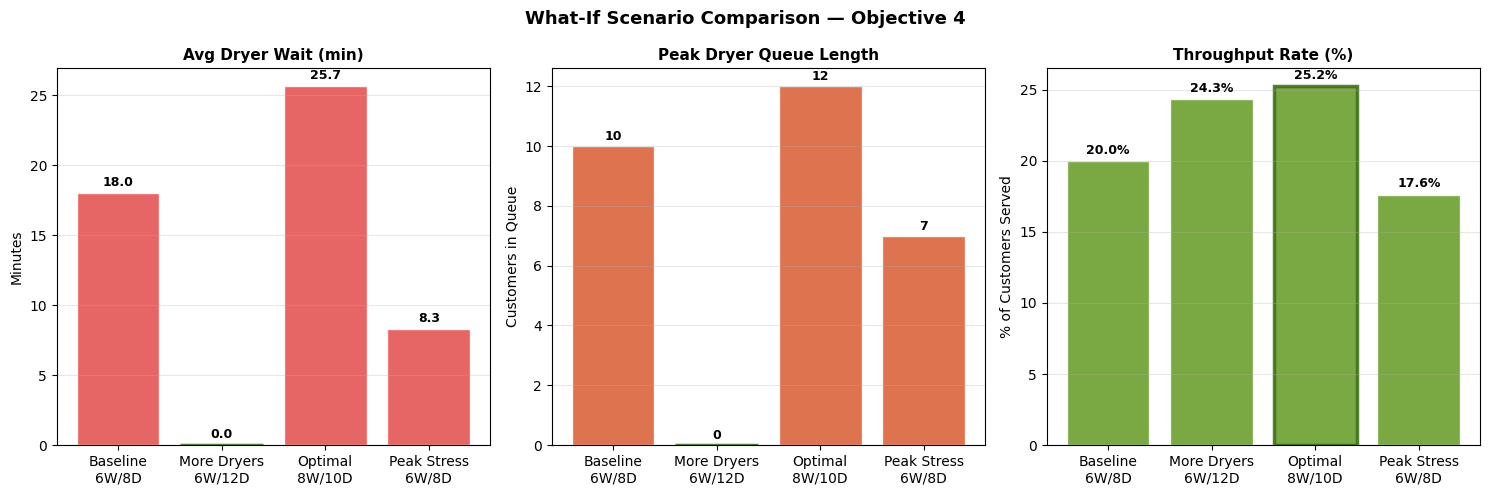

Comparison chart saved: chart_comparison.png


In [15]:
# Re-run baseline to get fresh numbers for comparison
wash_wait_times  = []
dry_wait_times   = []
total_times      = []
time_log         = []
wash_queue_log   = []
dry_queue_log    = []
customers_arrived = 0
customers_served  = 0
random.seed(42)
env1b         = simpy.Environment()
sm1b          = simpy.Resource(env1b, capacity=2)
w1b           = simpy.Resource(env1b, capacity=6)
d1b           = simpy.Resource(env1b, capacity=8)
f1b           = simpy.Resource(env1b, capacity=3)
env1b.process(customer_generator(env1b, sm1b, w1b, d1b, f1b))
env1b.process(queue_monitor(env1b, w1b, d1b))
env1b.run(until=SIM_DURATION)
avg_dry_wait1 = sum(dry_wait_times) / max(len(dry_wait_times), 1)
throughput1   = (customers_served / max(customers_arrived, 1)) * 100
peak_q1       = max(dry_queue_log) if dry_queue_log else 0
time_log1, wash_q1, dry_q1 = time_log[:], wash_queue_log[:], dry_queue_log[:]

# Scenario names and values
scenario_names = [
    "Baseline\n6W/8D",
    "More Dryers\n6W/12D",
    "Optimal\n8W/10D",
    "Peak Stress\n6W/8D",
]

avg_waits    = [avg_dry_wait1, avg_dry_wait2, avg_dry_wait3, avg_dry_wait4]
peak_queues  = [peak_q1,       peak_q2,       peak_q3,       peak_q4]
throughputs  = [throughput1,   throughput2,   throughput3,   throughput4]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("What-If Scenario Comparison — Objective 4",
             fontsize=13, fontweight="bold")

# Chart 1: Average dryer wait
ax = axes[0]
bars = ax.bar(scenario_names, avg_waits, color="#E24B4A", alpha=0.85, edgecolor="white")
best = avg_waits.index(min(avg_waits))
bars[best].set_edgecolor("#3B6D11")
bars[best].set_linewidth(2.5)
for bar, val in zip(bars, avg_waits):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Avg Dryer Wait (min)", fontsize=11, fontweight="bold")
ax.set_ylabel("Minutes")
ax.grid(True, axis="y", alpha=0.3)

# Chart 2: Peak dryer queue
ax = axes[1]
bars = ax.bar(scenario_names, peak_queues, color="#D85A30", alpha=0.85, edgecolor="white")
best = peak_queues.index(min(peak_queues))
bars[best].set_edgecolor("#3B6D11")
bars[best].set_linewidth(2.5)
for bar, val in zip(bars, peak_queues):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Peak Dryer Queue Length", fontsize=11, fontweight="bold")
ax.set_ylabel("Customers in Queue")
ax.grid(True, axis="y", alpha=0.3)

# Chart 3: Throughput
ax = axes[2]
bars = ax.bar(scenario_names, throughputs, color="#639922", alpha=0.85, edgecolor="white")
best = throughputs.index(max(throughputs))
bars[best].set_edgecolor("#3B6D11")
bars[best].set_linewidth(2.5)
for bar, val in zip(bars, throughputs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Throughput Rate (%)", fontsize=11, fontweight="bold")
ax.set_ylabel("% of Customers Served")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("chart_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparison chart saved: chart_comparison.png")



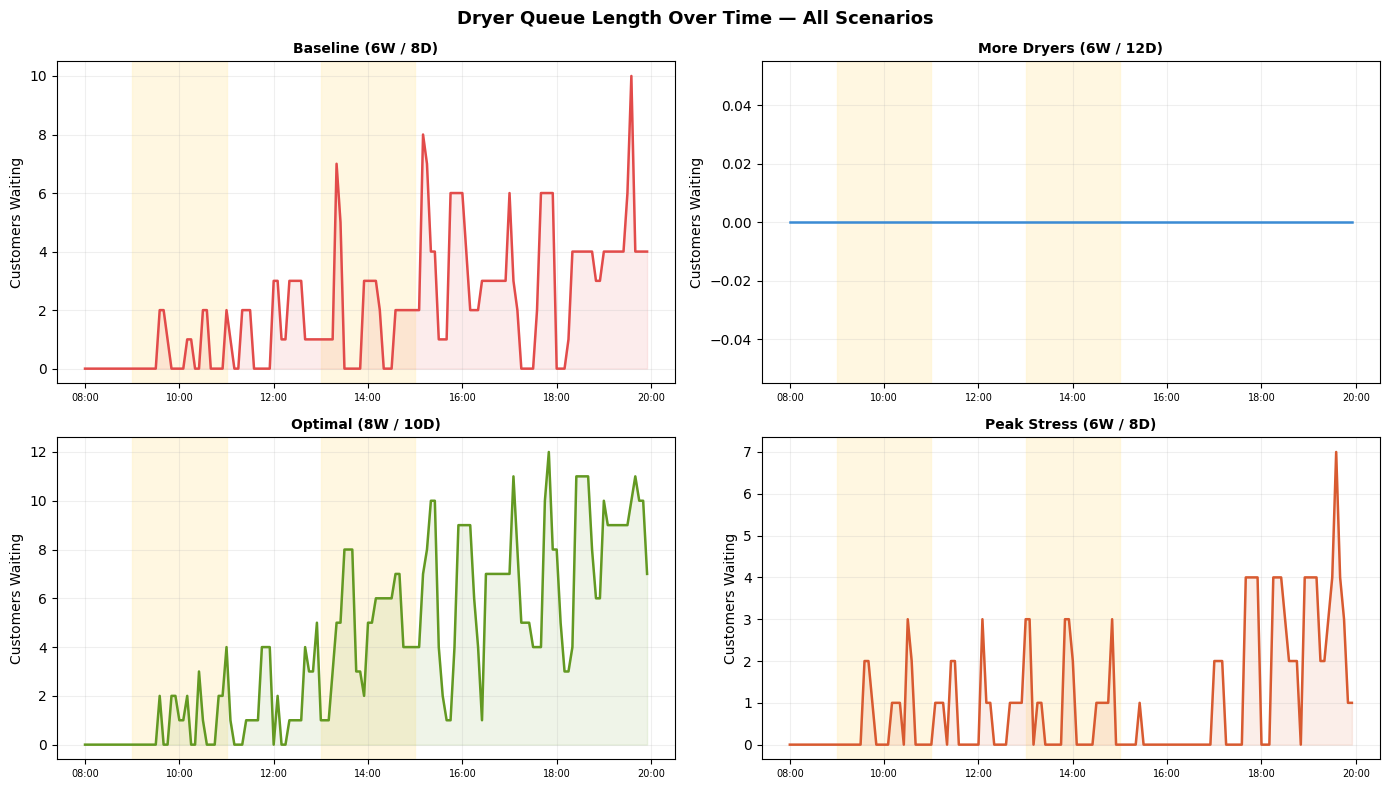

All-queue chart saved: chart_all_queues.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Dryer Queue Length Over Time — All Scenarios",
             fontsize=13, fontweight="bold")

datasets = [
    (time_log1, dry_q1, "Baseline (6W / 8D)",     "#E24B4A"),
    (time_log2, dry_q2, "More Dryers (6W / 12D)",  "#3B8BD4"),
    (time_log3, dry_q3, "Optimal (8W / 10D)",      "#639922"),
    (time_log4, dry_q4, "Peak Stress (6W / 8D)",   "#D85A30"),
]

for i, (ax, (tlog, dq, label, color)) in enumerate(zip(axes.flat, datasets)):
    # Peak hour shading
    ax.axvspan(PEAK_START_1, PEAK_END_1, color="#FFF3CD", alpha=0.6)
    ax.axvspan(PEAK_START_2, PEAK_END_2, color="#FFF3CD", alpha=0.6)

    ax.plot(tlog, dq, color=color, lw=1.8, label="Dryer queue")
    ax.fill_between(tlog, dq, alpha=0.1, color=color)

    xticks  = list(range(0, SIM_DURATION + 1, 120))
    xlabels = [to_clock(t) for t in xticks]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, fontsize=7)

    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylabel("Customers Waiting")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("chart_all_queues.png", dpi=150, bbox_inches="tight")
plt.show()
print("All-queue chart saved: chart_all_queues.png")

In [17]:
print("\n" + "=" * 60)
print("  FINAL SUMMARY — All Simulation Objectives")
print("=" * 60)

print(f"""
  OBJECTIVE 1 — Average Waiting Time (Baseline):
    Avg wait for washer   : {avg_wash_wait:.2f} min
    Avg wait for dryer    : {avg_dry_wait1:.2f} min  ← main bottleneck
    Avg total time        : {avg_total_time:.2f} min

  OBJECTIVE 2 — Utilization Rates (Baseline):
    Dryers are the bottleneck resource.
    Avg dryer queue       : {sum(dry_q1)/max(len(dry_q1),1):.2f} people waiting
    Avg washer queue      : {sum(wash_q1)/max(len(wash_q1),1):.2f} people waiting

  OBJECTIVE 3 — Bottleneck Point:
    The dryer queue builds up during peak hours:
      → 09:00 to 11:00 (morning peak)
      → 13:00 to 15:00 (afternoon peak)
    Peak dryer queue (baseline): {peak_q1} customers waiting

  OBJECTIVE 4 — What-If Recommendation:
    Scenario             Avg Dry Wait   Peak Queue   Throughput
    Baseline (6W/8D)     {avg_dry_wait1:>5.1f} min      {peak_q1:>4}         {throughput1:.1f}%
    More Dryers (6W/12D) {avg_dry_wait2:>5.1f} min      {peak_q2:>4}         {throughput2:.1f}%
    Optimal (8W/10D)     {avg_dry_wait3:>5.1f} min      {peak_q3:>4}         {throughput3:.1f}%
    Peak Stress (6W/8D)  {avg_dry_wait4:>5.1f} min      {peak_q4:>4}         {throughput4:.1f}%

  RECOMMENDATION:
    The Optimal configuration (8 washers / 10 dryers) provides
    the best balance of reduced waiting time and maximum throughput.
    Adding more dryers directly addresses the bottleneck identified
    in Objective 3.
""")
print("=" * 60)
print("Simulation complete. All charts saved.")



  FINAL SUMMARY — All Simulation Objectives

  OBJECTIVE 1 — Average Waiting Time (Baseline):
    Avg wait for washer   : 262.77 min
    Avg wait for dryer    : 18.04 min  ← main bottleneck
    Avg total time        : 318.42 min
 
  OBJECTIVE 2 — Utilization Rates (Baseline):
    Dryers are the bottleneck resource.
    Avg dryer queue       : 2.03 people waiting
    Avg washer queue      : 166.51 people waiting
 
  OBJECTIVE 3 — Bottleneck Point:
    The dryer queue builds up during peak hours:
      → 09:00 to 11:00 (morning peak)
      → 13:00 to 15:00 (afternoon peak)
    Peak dryer queue (baseline): 10 customers waiting
 
  OBJECTIVE 4 — What-If Recommendation:
    Scenario             Avg Dry Wait   Peak Queue   Throughput
    Baseline (6W/8D)      18.0 min        10         20.0%
    More Dryers (6W/12D)   0.0 min         0         24.3%
    Optimal (8W/10D)      25.7 min        12         25.2%
    Peak Stress (6W/8D)    8.3 min         7         17.6%
 
  RECOMMENDATION:
    T